# Sandbox for exploratory data analysis (EDA) using netflix TV shows database

Import nescessary modules and load dataset to `pandas.DataFrame`

In [4]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

'''
Datasets for sandbox were downloaded from kaggle
'''

df = pd.read_csv('netflix_tv_shows_detailed_up_to_2025.csv', index_col='show_id')

The number of records in each column, type of data, whether any values are missing and how much memory the dataset uses.

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 16000 entries, 33238 to 251815
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   type          16000 non-null  str    
 1   title         16000 non-null  str    
 2   director      5035 non-null   str    
 3   cast          14843 non-null  str    
 4   country       14203 non-null  str    
 5   date_added    16000 non-null  str    
 6   release_year  16000 non-null  int64  
 7   rating        16000 non-null  float64
 8   duration      16000 non-null  str    
 9   genres        15026 non-null  str    
 10  language      16000 non-null  str    
 11  description   12794 non-null  str    
 12  popularity    16000 non-null  float64
 13  vote_count    16000 non-null  int64  
 14  vote_average  16000 non-null  float64
dtypes: float64(3), int64(2), str(10)
memory usage: 7.9 MB
None


Incontrast to movies *duration* column is NOT empty but some columns, i.e. *director* or *cast*, still have empty (null) values. The code below will generate a statistical summary of the `movies_df` DataFrame showing values like count, mean, standard deviation, minimum and quartiles for each numerical column.

In [6]:
df['date_added'] = pd.to_datetime(df['date_added'])

df.describe(include=np.number).T

,count,mean,std,min,25%,50%,75%,max
release_year,16000.0,2017.500000,4.609916,2010.000,2013.75000,2017.5000,2021.2500,2025.000
rating,16000.0,5.417107,3.266492,0.000,2.70000,6.8000,7.8000,10.000
popularity,16000.0,64.850984,139.387289,2.323,24.87475,36.1875,62.1875,6421.923
vote_count,16000.0,107.014313,607.461581,0.000,1.00000,4.0000,30.0000,24664.000
vote_average,16000.0,5.417107,3.266492,0.000,2.70000,6.8000,7.8000,10.000


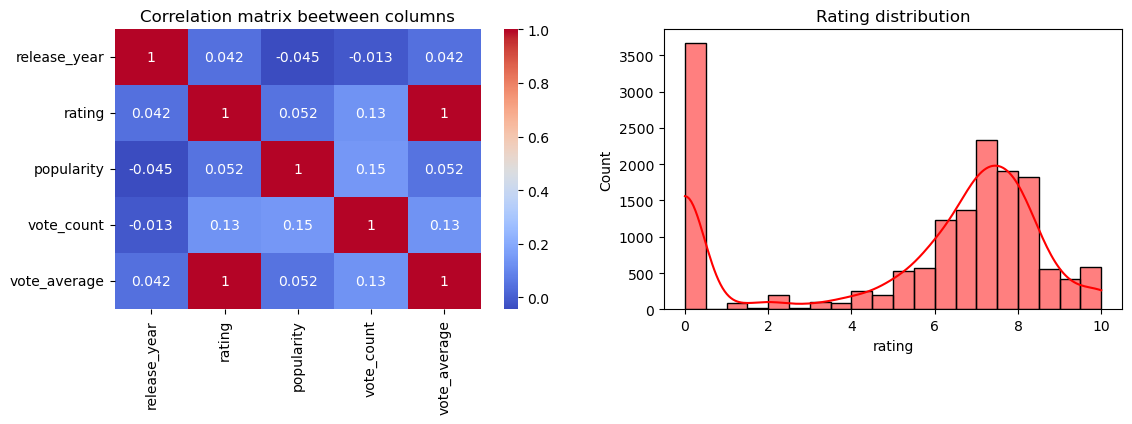

In [7]:
plt.figure(figsize=(13,8))
plt.subplot(221)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation matrix beetween columns')
plt.subplot(222)
sns.histplot(df['rating'], bins=20, kde=True, color='red')
plt.title('Rating distribution')
plt.show()

Correlation beetween `vote_average` and `rating` is exactly 1 which means that it's probably duplicated and one should be removed.
Rating distribution histogram show a strong jump (much more significant than in case of movies) at rating equal to 0 which may mean no rating for some TV shows and should be trated as noise that may impact further analisys.

In [8]:
if 'vote_average' in df.columns: df.drop(columns=['vote_average'], inplace=True)
df = df[df['rating'] > 0]

df.describe(include=[float, int]).T

,count,mean,std,min,25%,50%,75%,max
release_year,12327.0,2017.527379,4.414645,2010.000,2014.0000,2018.000,2021.0000,2025.000
rating,12327.0,7.031209,1.580975,0.500,6.3000,7.200,8.0000,10.000
popularity,12327.0,70.337299,154.093974,2.418,26.2185,37.927,65.8555,6421.923
vote_count,12327.0,138.899732,688.869263,0.000,2.0000,9.000,54.0000,24664.000


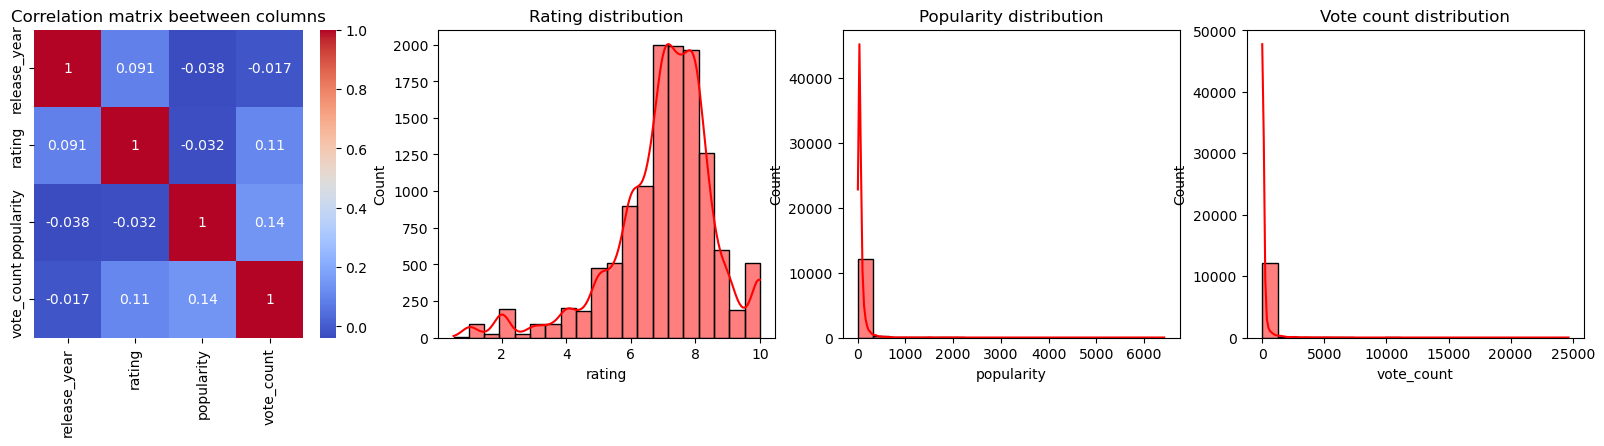

In [10]:
plt.figure(figsize=(20,4))
plt.subplot(141)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation matrix beetween columns')
plt.subplot(142)
sns.histplot(df['rating'], bins=20, kde=True, color='red')
plt.title('Rating distribution')
plt.subplot(143)
sns.histplot(df['popularity'], bins=20, kde=True, color='red')
plt.title('Popularity distribution')
plt.subplot(144)
sns.histplot(df['vote_count'], bins=20, kde=True, color='red')
plt.title('Vote count distribution')
plt.show()

Stron peak at o for `popularity` and `vote_count` may also mean missing data therefore they're removed from dataset

In [13]:
df = df[(df['popularity'] > 0) & (df['vote_count'] > 0)]
df.describe(include=[float, int]).T

,count,mean,std,min,25%,50%,75%,max
release_year,12314.0,2017.526393,4.414725,2010.000,2014.00000,2018.0000,2021.0000,2025.000
rating,12314.0,7.030592,1.579150,0.500,6.30000,7.2000,8.0000,10.000
popularity,12314.0,70.357677,154.166358,2.418,26.22575,37.9545,65.8375,6421.923
vote_count,12314.0,139.046370,689.218027,1.000,2.00000,9.0000,54.0000,24664.000


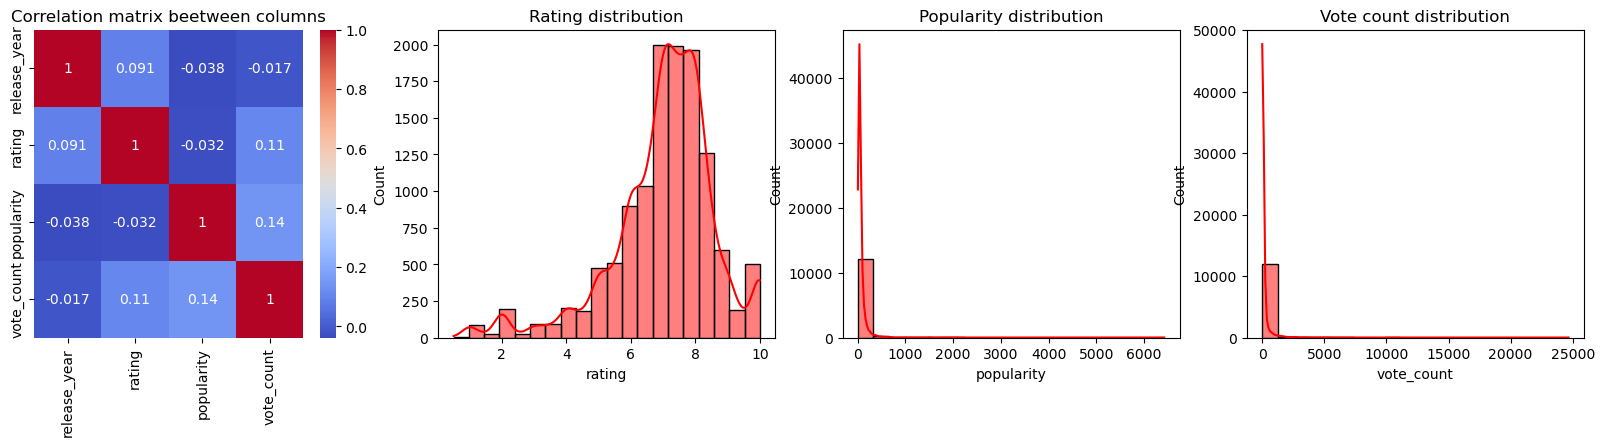

In [14]:
plt.figure(figsize=(20,4))
plt.subplot(141)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation matrix beetween columns')
plt.subplot(142)
sns.histplot(df['rating'], bins=20, kde=True, color='red')
plt.title('Rating distribution')
plt.subplot(143)
sns.histplot(df['popularity'], bins=20, kde=True, color='red')
plt.title('Popularity distribution')
plt.subplot(144)
sns.histplot(df['vote_count'], bins=20, kde=True, color='red')
plt.title('Vote count distribution')
plt.show()

`Seaborn.pairplot` visualizes pairwise relationships between variables in a dataset, creating a grid of plots.

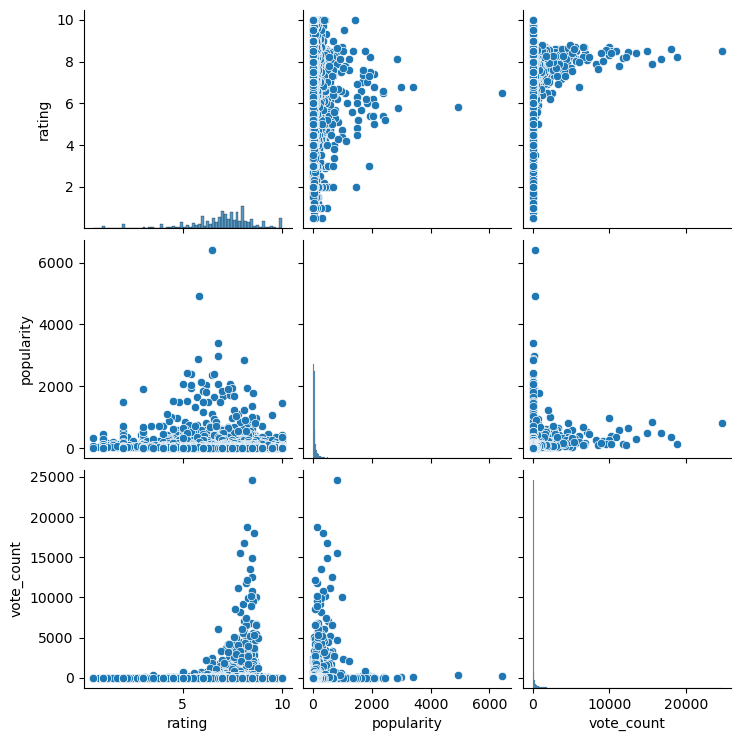

In [15]:
sns.pairplot(df.drop(columns=['release_year']))

Grouping data by popularity using `pandas.qcut`

According to [pandas documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html): 
quantile-based discretization function. In case of `q=4` it's divided into 4 equal 'buckets' 

In [17]:
df['popularity_range'] = pd.qcut(df['popularity'], q=4, labels=['Unknown', 'Niche', 'High demand', 'Hot'])
budget_analysis = df.groupby('popularity_range')['rating'].mean()
print('Rating by popularity:', budget_analysis)

Rating by popularity: popularity_range
Unknown        7.010029
Niche          7.052153
High demand    7.076259
Hot            6.983950
Name: rating, dtype: float64


To analyze data by genres, a new dataset must be created using `DataFrame.groupby` method and math dunctions like `mean`.

In [19]:
df_genres = df.copy()
df_genres['genres'] = df['genres'].str.split(', ')
df_genres = df_genres.explode('genres')
genres_analisys = df_genres.groupby('genres').agg({
    'popularity': 'mean',
    'vote_count': 'mean',
    'rating':     'mean',
    'genres':     'count'
}).rename(columns={'genres': 'tv_shows_count'}).sort_values(by='rating', ascending=False)
print(genres_analisys.to_string())

                    popularity  vote_count    rating  tv_shows_count
genres                                                              
War & Politics       56.856258  154.118852  7.475287             244
Documentary          49.924344   43.675000  7.414944             640
Action & Adventure   70.151558  314.040771  7.401462            1815
Sci-Fi & Fantasy     63.172888  393.876751  7.396129            1785
Animation            58.421582  151.232568  7.341741            2266
Western             104.118038  531.038462  7.256385              26
Kids                 70.115559   74.371681  7.233776             678
Crime                65.155510  271.994648  7.225479            1308
Mystery              58.452249  282.231544  7.209839            1192
Comedy               69.135270  110.838858  7.063943            3922
Drama                67.066841  192.786028  7.060590            6370
Family               86.628830   68.964551  6.985641            1213
Reality              90.478507   1

<Axes: title={'center': 'Mean popularity and vote_count over the years'}, xlabel='release_year'>

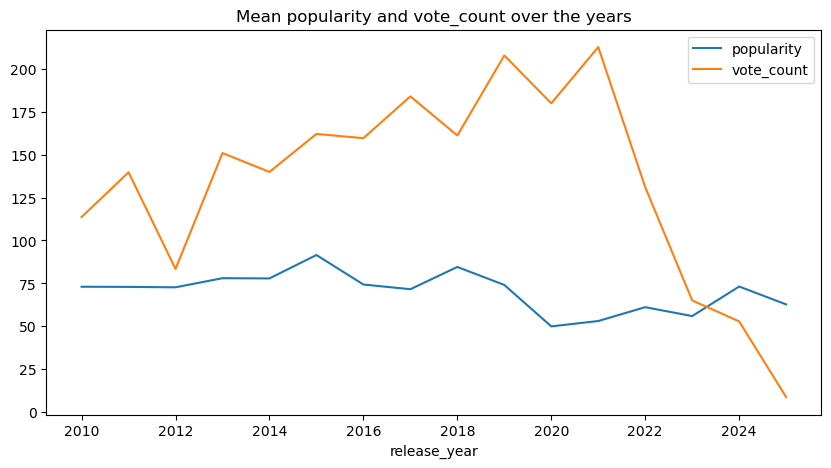

In [20]:
yearly_trends = df.groupby('release_year').agg({
    'popularity':  'mean',
    'vote_count': 'mean'
})

# Wykres liniowy trendów
yearly_trends[['popularity', 'vote_count']].plot(figsize=(10,5), title='Mean popularity and vote_count over the years')